In [6]:
import pandas as pd
from pandas.io.formats.style import Styler # Para a tipagem do retorno

def analisar_risco(df: pd.DataFrame, coluna: str) -> Styler:
    """
    Gera uma tabela de frequência bivariada analisando o risco (target)
    por categoria de uma coluna específica.
    
    Args:
        df (pd.DataFrame): O DataFrame contendo os dados.
        coluna (str): O nome da coluna categórica a ser analisada.
        
    Returns:
        pd.io.formats.style.Styler: Objeto de estilo do Pandas para visualização.
    """
    
    # --- 1. ASSERTS (O "Crachá de Segurança") ---
    # Garante que o df é mesmo um DataFrame
    assert isinstance(df, pd.DataFrame), "Erro: O argumento 'df' precisa ser um Pandas DataFrame."
    
    # Garante que a coluna existe (evita aquele erro gigante de KeyError depois)
    assert coluna in df.columns, f"Erro: A coluna '{coluna}' não foi encontrada no DataFrame."
    
    # Garante que o target existe (premissa básica da função)
    assert 'target' in df.columns, "Erro: O DataFrame precisa ter uma coluna chamada 'target'."
    
    # Garante que não estamos analisando um dataset vazio
    assert not df.empty, "Erro: O DataFrame está vazio!"

    # --- 2. LÓGICA DE NEGÓCIO ---
    # Agrupa e calcula
    tabela = df.groupby(coluna)['target'].agg(['count', 'mean'])
    
    # Renomeia
    tabela.columns = ['Qtd_Clientes', 'Bad_Rate']
    
    # Ordena do maior risco para o menor
    tabela = tabela.sort_values(by='Bad_Rate', ascending=False)
    
    # --- 3. RETORNO VISUAL ---
    print(f"--- Relatório de Risco: {coluna.upper()} ---")
    media_geral = df['target'].mean()
    print(f"Média Geral do Portfólio: {media_geral:.2%}\n")
    
    return tabela.style.format({
        'Bad_Rate': '{:.2%}',
        'Qtd_Clientes': '{:,}'
    }).background_gradient(cmap='Reds', subset='Bad_Rate')

# Nomes das colunas baseados na documentação "german.doc"
col_names = [
    'checking_account', 'duration_months', 'credit_history', 'purpose', 
    'credit_amount', 'savings_account', 'employment_since', 'installment_rate', 
    'status_sex', 'other_debtors', 'residence_since', 'property', 
    'age', 'other_installment_plans', 'housing','existing_credits',
    'job', 'people_liable', 'telephone', 'foreign_worker', 'target'
]

# Carregando o arquivo cru (sem header), separando por espaço
#url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
df = pd.read_csv("D:\\Projetos\\CreditScore\\UCIRepository\\german.data", sep=' ', header=None, names=col_names)

# Ajuste Rápido no Target para o padrão de mercado (0 e 1)
# Original: 1 (Bom), 2 (Ruim)
# Padrão Data Science: 0 (Bom/Não-Evento), 1 (Ruim/Evento/Fraude)
# df['target'] = df['target'].map({1: 0, 2: 1})

# Visualizar
# print(df.head())


In [10]:
### VERSAO DE PRE PROCESSAMENTO
import pandas as pd
import numpy as np

def aplicar_mapeamento_estrategico(df_input):
    """
    Aplica todas as regras de negócio e agrupamentos de risco definidos
    na fase de análise exploratória.
    Retorna: DataFrame com colunas _cat (categóricas tratadas).
    """
    df = df_input.copy()

    # --- 1. Dicionários de Mapeamento (A Regra de Negócio) ---
    
    # A1: Checking Account (Status da Conta Corrente)
    map_checking = {
        'A14': '1_sem_conta',       # Neutro/Baixo Risco
        'A11': '3_negativo',        # Alto Risco (< 0 DM)
        'A12': '2_medio',           # 0 <= x < 200 DM
        'A13': '1_alto_saldo'       # >= 200 DM / Salário
    }

    # A3: Credit History (Histórico) - Padronizado
    map_history = {
        'A34': '1_critica_existente', # O banco conhece e confia
        'A32': '2_pagou_em_dia',      # Histórico normal
        'A33': '2_atraso_passado',    # Teve problemas mas pagou
        'A30': '3_sem_credito',       # Desconhecido (Risco)
        'A31': '3_pagou_tudo_aqui'    # Quitados (Cliente "sumiu" do radar)
    }

    # A4/A5: Purpose (Finalidade) - Agrupado por Risco
    map_purpose = {
        'A43': '1_eletronicos', # Radio/TV (Baixo Risco)
        'A41': '1_carro_usado',
        'A48': '1_retraining',
        'A42': '2_mobilia',     # Furniture/Equipment
        'A44': '2_eletro',      # Domestic Appliances
        'A40': '3_carro_novo',  # Alto Risco
        'A46': '3_educacao',
        'A49': '3_negocios',
        'A45': '3_negocios',
        'A410': '3_outros'
    }

    # A6: Savings (Poupança)
    map_savings = {
        'A64': '1_rico',        # >= 1000 DM
        'A63': '2_medio_alto',  # 500 <= x < 1000
        'A62': '2_medio',       # 100 <= x < 500
        'A61': '3_pobre',       # < 100 DM
        'A65': '3_sem_poupanca' # Unknown
    }

    # A9: Personal Status & Sex
    map_personal = {
        'A93': '1_homem_solteiro', # Baixo Risco
        'A94': '1_homem_casado',
        'A92': '2_mulher',         # Risco Médio/Alto (Viés histórico do dataset)
        'A91': '2_homem_divorciado'
    }

    # A12: Property (Garantias)
    map_property = {
        'A121': '1_imovel',   # Real Estate
        'A122': '2_seguro_vida',
        'A123': '2_carro_outros',
        'A124': '3_sem_propriedade'
    }

    # A14: Other Installments (Outras dívidas)
    map_installments = {
        'A143': '1_nenhuma', # Sem dívidas extras
        'A141': '2_banco',   # Deve a outro banco
        'A142': '2_lojas'    # Deve a lojas
    }

    # A17: Job (Emprego)
    map_job = {
        'A171': '1_comum',
        'A172': '1_comum',
        'A173': '1_comum',
        'A174': '2_gestao_autonomo' # Maior risco neste dataset
    }

    # --- 2. Aplicação dos Mapas ---
    df['cat_checking'] = df['checking_account'].map(map_checking)
    df['cat_history']  = df['credit_history'].map(map_history)
    df['cat_purpose']  = df['purpose'].map(map_purpose)
    df['cat_savings']  = df['savings_account'].map(map_savings)
    df['cat_personal'] = df['status_sex'].map(map_personal) 
    df['cat_property'] = df['property'].map(map_property)
    df['cat_install']  = df['other_installment_plans'].map(map_installments)
    df['cat_job']      = df['job'].map(map_job)

    # Variáveis binárias simples (Já mapeamos para 1 e 2)
    df['cat_telephone'] = df['telephone'].map({'A192': '1_sim', 'A191': '2_nao'})
    df['cat_foreign']   = df['foreign_worker'].map({'A202': '1_nao', 'A201': '2_sim'})

    return df

def tratar_variaveis_numericas(df_input):
    """
    Aplica transformações matemáticas e Binning nas numéricas.
    """
    df = df_input.copy()

    # 1. Duration: Logaritmo (suaviza a cauda longa)
    # Adicionamos +1 para evitar log(0) se houvesse, embora aqui min seja 4.
    df['num_duration_log'] = np.log1p(df['duration_months'])

    # 2. Credit Amount: Binning em "U" (Baseado nos Quartis)
    # < 1365 (Risco Médio/Alto) | 1365-3972 (Seguro) | > 3972 (Risco Alto)
    def class_amount(x):
        if x < 1365: return '2_valor_baixo'
        elif x < 3972: return '1_valor_seguro'
        else: return '3_valor_alto'
    
    df['cat_amount_bin'] = df['credit_amount'].apply(class_amount)

    # 3. Age: Binning de Risco (Jovens vs O Resto)
    # < 27 (Alto) | 27-33 (Médio) | > 33 (Baixo)
    def class_age(x):
        if x < 27: return '3_jovem'
        elif x < 33: return '2_adulto'
        else: return '1_senior'

    df['cat_age_bin'] = df['age'].apply(class_age)

    return df

def pipeline_final(df_raw):
    """
    Orquestrador final. Recebe o raw, trata e devolve X e y prontos.
    """
    # 1. Tratamentos
    df_step1 = aplicar_mapeamento_estrategico(df_raw)
    df_step2 = tratar_variaveis_numericas(df_step1)

    # 2. Seleção de Colunas
    # Pegamos apenas as colunas criadas ('cat_' e 'num_')
    # Ignoramos as colunas originais 'sujas'
    cols_to_keep = [c for c in df_step2.columns if c.startswith('cat_') or c.startswith('num_')]
    
    # Adicionar o Target se existir (ajuste o nome 'class' ou 'target')
    target_col = 'target' # Supondo que o nome seja 'class' (1=Good, 2=Bad)
    if target_col in df_step2.columns:
        # Padronizando Target: 0 = Bom, 1 = Mau (Bad)
        # No dataset original: 1=Good, 2=Bad. Vamos transformar.
        df_step2['target_final'] = df_step2[target_col].map({1: 0, 2: 1})
        cols_to_keep.append('target_final')

    df_clean = df_step2[cols_to_keep].copy()

    # 3. One-Hot Encoding (Dummies)
    # drop_first=True é CRUCIAL para evitar a "Dummy Variable Trap" (Multicolinearidade perfeita)
    # Ex: Se tenho Jovem, Adulto, Senior -> Só preciso de colunas para Jovem e Adulto. 
    # Se ambas forem 0, sei que é Senior.
    df_model = pd.get_dummies(df_clean, drop_first=True, dtype=int)
    
    return df_model

# --- Execução ---
df_final = pipeline_final(df)
# print(df_final.info())
# print(df_final.head())

In [11]:
## SEPARANDO AS VARIAVEIS DE TESTE E TREINAMENTO
from sklearn.model_selection import train_test_split

# Supondo que df_final é o dataframe que saiu do pipeline anterior
# X = Tudo menos o alvo
X = df_final.drop('target_final', axis=1)

# y = Apenas o alvo (0=Bom, 1=Mau)
y = df_final['target_final']


In [12]:
#  ESTRATIFICANDO NOSSA BASE PARA NÃO COMPROMETER O TREINAMENTO COM VIÉS.
#  Dividindo: 70% para o robô estudar (Treino), 30% para a prova (Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, # Para garantir que o resultado seja sempre o mesmo
    stratify=y       # Mantém a proporção de Bom/Mau igual nas duas partes
)

print(f"Treino: {X_train.shape[0]} clientes | Teste: {X_test.shape[0]} clientes")

Treino: 700 clientes | Teste: 300 clientes


=== TREINANDO MODELO XGBOOST ===

--- Relatório XGBoost (Corte: 15.0%) ---
              precision    recall  f1-score   support

           0       0.88      0.48      0.62       210
           1       0.41      0.84      0.55        90

    accuracy                           0.59       300
   macro avg       0.64      0.66      0.58       300
weighted avg       0.74      0.59      0.60       300

ROC-AUC Score XGBoost: 0.7316


c:\Users\oguis\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


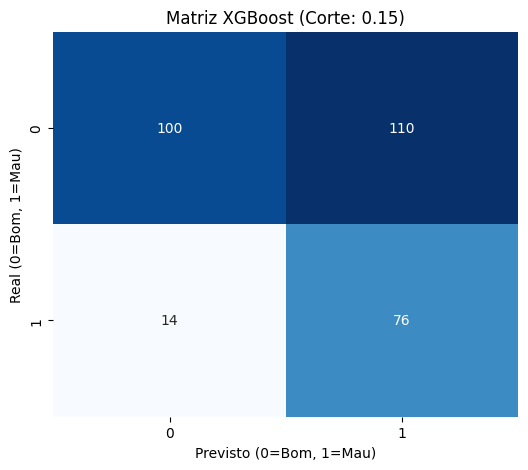

In [27]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== TREINANDO MODELO XGBOOST ===")

# O XGBoost tem um parâmetro específico para dados desbalanceados chamado 'scale_pos_weight'
# Geralmente, ele é a razão: (Total da Classe Negativa) / (Total da Classe Positiva)
# No nosso caso (700 Bons / 300 Maus), seria algo perto de 700/300 = 2.33
razao_desbalanceamento = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=razao_desbalanceamento, # <-- Substitui o class_weight do RF
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Previsões com o modelo puro
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Vamos aplicar direto aquele seu corte cirúrgico de 47% (0.47)
corte_xgb = 0.15
y_pred_xgb_custom = (y_proba_xgb >= corte_xgb).astype(int)

print(f"\n--- Relatório XGBoost (Corte: {corte_xgb*100}%) ---")
print(classification_report(y_test, y_pred_xgb_custom))

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"ROC-AUC Score XGBoost: {auc_xgb:.4f}")

# Matriz de confusão
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_xgb_custom)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz XGBoost (Corte: {corte_xgb})')
plt.xlabel('Previsto (0=Bom, 1=Mau)')
plt.ylabel('Real (0=Bom, 1=Mau)')
plt.show()